# BUSI End-to-End v2


:

---
## 0. Setup

In [ ]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from IPython.display import clear_output
!pip install -q opencv-python-headless scikit-learn
clear_output()
print("Packages ready.")

Packages ready.


In [ ]:
# === Paths & global config ===
import os, json, random, gc
import numpy as np

DRIVE_ROOT     = '/content/drive/MyDrive/breast cancer- segment'
BUSI_DIR       = os.path.join(DRIVE_ROOT, 'Dataset_BUSI_with_GT')

INTEG_DIR      = os.path.join(DRIVE_ROOT, 'integrated_v1')   # reuse v1 artifacts
UNET_WEIGHTS   = os.path.join(INTEG_DIR, 'unet_busi.weights.h5')
SPLIT_PATH     = os.path.join(INTEG_DIR, 'split_manifest.json')
PROCESSED_DIR  = os.path.join(INTEG_DIR, 'processed')
CLF_WEIGHTS    = os.path.join(INTEG_DIR, 'classifier_v2.pth')   # v2 -> new file
os.makedirs(INTEG_DIR, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)

SIZE = 256
SEED = 42

# >>> If you already ran v1 successfully, set BOTH to True to skip Stage A+B <<<
SKIP_UNET_TRAINING = True
SKIP_BRIDGE        = True

THREE_CLASS  = {'benign': 0, 'malignant': 1, 'normal': 2}
TO_BINARY    = {0: 0, 1: 1, 2: 0}
BINARY_NAMES = ['Non-malignant', 'Malignant']

random.seed(SEED); np.random.seed(SEED)
assert os.path.exists(BUSI_DIR), f'BUSI dataset not found at {BUSI_DIR}'
print('SKIP_UNET_TRAINING:', SKIP_UNET_TRAINING)
print('SKIP_BRIDGE       :', SKIP_BRIDGE)
print('Classifier weights:', CLF_WEIGHTS)

SKIP_UNET_TRAINING: True
SKIP_BRIDGE       : True
Classifier weights: /content/drive/MyDrive/breast cancer- segment/integrated_v1/classifier_v2.pth


---
## 1. Data Preparation (same as v1)

In [ ]:
from glob import glob

def collect_busi(busi_dir):
    items = []
    for cls_name, cls_idx in THREE_CLASS.items():
        cls_dir = os.path.join(busi_dir, cls_name)
        for mp in sorted(glob(os.path.join(cls_dir, '*_mask.png'))):
            stem = os.path.basename(mp).replace('_mask.png', '')
            ip = os.path.join(cls_dir, stem + '.png')
            if not os.path.exists(ip):
                continue
            extras = sorted(glob(os.path.join(cls_dir, f'{stem}_mask_*.png')))
            items.append({'image_path': ip, 'mask_paths': [mp] + extras,
                          'cls': cls_idx, 'stem': f'{cls_name}_{stem}'})
    return items

all_items = collect_busi(BUSI_DIR)
counts = {k: sum(1 for x in all_items if x['cls'] == v) for k, v in THREE_CLASS.items()}
print(f'Total: {len(all_items)} | per-class: {counts}')

Total: 780 | per-class: {'benign': 437, 'malignant': 210, 'normal': 133}


In [ ]:
from sklearn.model_selection import train_test_split

if os.path.exists(SPLIT_PATH):
    with open(SPLIT_PATH) as f:
        manifest = json.load(f)
    print(f'Loaded existing split from {SPLIT_PATH}')
else:
    labels = [x['cls'] for x in all_items]
    train_items, temp_items, _, temp_lbl = train_test_split(
        all_items, labels, test_size=0.4, stratify=labels, random_state=SEED)
    val_items, test_items = train_test_split(
        temp_items, test_size=0.5, stratify=temp_lbl, random_state=SEED)
    manifest = {
        'train': [x['stem'] for x in train_items],
        'val'  : [x['stem'] for x in val_items],
        'test' : [x['stem'] for x in test_items],
    }
    with open(SPLIT_PATH, 'w') as f:
        json.dump(manifest, f, indent=2)
    print('Saved split.')

by_stem = {x['stem']: x for x in all_items}
train_items = [by_stem[s] for s in manifest['train']]
val_items   = [by_stem[s] for s in manifest['val']]
test_items  = [by_stem[s] for s in manifest['test']]
for n, items in [('train', train_items), ('val', val_items), ('test', test_items)]:
    cs = {0: 0, 1: 0, 2: 0}
    for x in items: cs[x['cls']] += 1
    print(f'{n:6s} n={len(items):4d} | benign={cs[0]} malignant={cs[1]} normal={cs[2]}')

Loaded existing split from /content/drive/MyDrive/breast cancer- segment/integrated_v1/split_manifest.json
train  n= 468 | benign=262 malignant=126 normal=80
val    n= 156 | benign=87 malignant=42 normal=27
test   n= 156 | benign=88 malignant=42 normal=26


---
## 2-3. Stage A + B — only runs if `SKIP_*` flags are False

In [ ]:
# Only import TF and run U-Net stuff if we actually need to
if not (SKIP_UNET_TRAINING and SKIP_BRIDGE):
    import tensorflow as tf
    import cv2
    from tensorflow.keras import Model, Input
    from tensorflow.keras.layers import (Layer, Conv2D, Dropout, UpSampling2D,
                                          MaxPool2D, BatchNormalization,
                                          Add, Multiply, concatenate)
    from tensorflow.keras.callbacks import ModelCheckpoint
    tf.keras.utils.set_random_seed(SEED)

    # === U-Net building blocks ===
    class EncoderBlock(Layer):
        def __init__(self, filters, rate, pooling=True, **kw):
            super().__init__(**kw)
            self.filters, self.rate, self.pooling = filters, rate, pooling
            self.c1 = Conv2D(filters, 3, padding='same', activation='relu', kernel_initializer='he_normal')
            self.dr = Dropout(rate)
            self.c2 = Conv2D(filters, 3, padding='same', activation='relu', kernel_initializer='he_normal')
            self.mp = MaxPool2D()
        def call(self, x):
            x = self.c2(self.dr(self.c1(x)))
            return (self.mp(x), x) if self.pooling else x
        def get_config(self):
            return {**super().get_config(),
                    'filters': self.filters, 'rate': self.rate, 'pooling': self.pooling}

    class DecoderBlock(Layer):
        def __init__(self, filters, rate, **kw):
            super().__init__(**kw)
            self.filters, self.rate = filters, rate
            self.up  = UpSampling2D()
            self.net = EncoderBlock(filters, rate, pooling=False)
        def call(self, x):
            x, skip = x
            x = self.up(x)
            return self.net(concatenate([x, skip]))
        def get_config(self):
            return {**super().get_config(), 'filters': self.filters, 'rate': self.rate}

    class AttentionGate(Layer):
        def __init__(self, filters, bn=True, **kw):
            super().__init__(**kw)
            self.filters, self.bn = filters, bn
            self.normal = Conv2D(filters, 3, padding='same', activation='relu', kernel_initializer='he_normal')
            self.down   = Conv2D(filters, 3, strides=2, padding='same', activation='relu', kernel_initializer='he_normal')
            self.learn  = Conv2D(1, 1, padding='same', activation='sigmoid')
            self.up     = UpSampling2D()
            self.bn_l   = BatchNormalization()
        def call(self, x):
            gate, skip = x
            a = self.learn(Add()([self.normal(gate), self.down(skip)]))
            a = self.up(a)
            f = Multiply()([a, skip])
            return self.bn_l(f) if self.bn else f
        def get_config(self):
            return {**super().get_config(), 'filters': self.filters, 'bn': self.bn}

    def build_unet(size=SIZE):
        inp = Input(shape=(size, size, 1))
        p1, c1 = EncoderBlock(32, 0.1, name='Enc1')(inp)
        p2, c2 = EncoderBlock(64, 0.1, name='Enc2')(p1)
        p3, c3 = EncoderBlock(128, 0.2, name='Enc3')(p2)
        p4, c4 = EncoderBlock(256, 0.2, name='Enc4')(p3)
        enc    = EncoderBlock(512, 0.3, pooling=False, name='Bottleneck')(p4)
        a1 = AttentionGate(256, name='Att1')([enc, c4]); d1 = DecoderBlock(256, 0.2, name='Dec1')([enc, a1])
        a2 = AttentionGate(128, name='Att2')([d1, c3]);  d2 = DecoderBlock(128, 0.2, name='Dec2')([d1, a2])
        a3 = AttentionGate(64, name='Att3')([d2, c2]);   d3 = DecoderBlock(64, 0.1, name='Dec3')([d2, a3])
        a4 = AttentionGate(32, name='Att4')([d3, c1]);   d4 = DecoderBlock(32, 0.1, name='Dec4')([d3, a4])
        out = Conv2D(1, 1, activation='sigmoid', padding='same')(d4)
        return Model(inp, out, name='AttentionUNet')

    def dice_coef(y_true, y_pred, smooth=1.0):
        y_pred = tf.cast(y_pred > 0.5, tf.float32)
        y_true = tf.cast(y_true, tf.float32)
        inter  = tf.reduce_sum(y_true * y_pred)
        return (2.*inter + smooth) / (tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth)

    def dice_loss(y_true, y_pred, smooth=1.0):
        inter = tf.reduce_sum(y_true * y_pred)
        return 1 - (2.*inter + smooth) / (tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth)

    def bce_dice(y_true, y_pred):
        return tf.keras.losses.binary_crossentropy(y_true, y_pred) + dice_loss(y_true, y_pred)

    def load_gray(path, size=SIZE):
        im = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if im is None: raise IOError(path)
        im = cv2.resize(im, (size, size), interpolation=cv2.INTER_LINEAR)
        return (im.astype(np.float32) / 255.)[..., None]

    def load_mask_union(mask_paths, size=SIZE):
        out = np.zeros((size, size), dtype=np.uint8)
        for p in mask_paths:
            m = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
            m = cv2.resize(m, (size, size), interpolation=cv2.INTER_NEAREST)
            out |= (m > 127).astype(np.uint8)
        return out[..., None].astype(np.float32)

    def items_to_arrays(items):
        n = len(items)
        X = np.zeros((n, SIZE, SIZE, 1), dtype=np.float32)
        Y = np.zeros((n, SIZE, SIZE, 1), dtype=np.float32)
        for i, x in enumerate(items):
            X[i] = load_gray(x['image_path'])
            Y[i] = load_mask_union(x['mask_paths'])
        return X, Y
else:
    print('SKIP_UNET_TRAINING and SKIP_BRIDGE both True — skipping all TF code.')

SKIP_UNET_TRAINING and SKIP_BRIDGE both True — skipping all TF code.


In [ ]:
# === Stage A: train U-Net (skipped if SKIP_UNET_TRAINING) ===
if not SKIP_UNET_TRAINING:
    print('Loading train+val into memory...')
    X_tr, Y_tr = items_to_arrays(train_items)
    X_va, Y_va = items_to_arrays(val_items)

    def augment(img, mask):
        if tf.random.uniform([]) > 0.5:
            img  = tf.image.flip_left_right(img); mask = tf.image.flip_left_right(mask)
        if tf.random.uniform([]) > 0.5:
            img  = tf.image.flip_up_down(img);    mask = tf.image.flip_up_down(mask)
        img = tf.image.random_brightness(img, 0.05)
        img = tf.image.random_contrast(img, 0.9, 1.1)
        img = tf.clip_by_value(img, 0., 1.)
        return img, mask

    BATCH_UNET, EPOCHS_UNET = 8, 25
    train_ds = (tf.data.Dataset.from_tensor_slices((X_tr, Y_tr))
                .shuffle(len(X_tr), seed=SEED)
                .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
                .batch(BATCH_UNET).prefetch(tf.data.AUTOTUNE))
    val_ds   = (tf.data.Dataset.from_tensor_slices((X_va, Y_va))
                .batch(BATCH_UNET).prefetch(tf.data.AUTOTUNE))

    unet = build_unet(SIZE)
    unet.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss=bce_dice, metrics=[dice_coef])
    cbs = [
        ModelCheckpoint(UNET_WEIGHTS, monitor='val_dice_coef', mode='max',
                        save_best_only=True, save_weights_only=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_dice_coef', mode='max',
                                              factor=0.5, patience=4, min_lr=1e-6),
    ]
    history = unet.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_UNET, callbacks=cbs)
    unet.load_weights(UNET_WEIGHTS)
    print(f'Best val dice: {max(history.history["val_dice_coef"]):.4f}')
elif not SKIP_BRIDGE:
    # Need U-Net loaded for Stage B
    unet = build_unet(SIZE)
    unet.load_weights(UNET_WEIGHTS)
    print(f'Loaded U-Net weights for Stage B inference.')

In [ ]:
# === Stage B: generate predicted masks (skipped if SKIP_BRIDGE) ===
if not SKIP_BRIDGE:
    from tqdm.auto import tqdm
    def stage_b_run(items, split_name):
        out_root = os.path.join(PROCESSED_DIR, split_name)
        n = 0
        for x in tqdm(items, desc=f'Stage B [{split_name}]'):
            cls_dir = os.path.join(out_root, str(x['cls']))
            os.makedirs(cls_dir, exist_ok=True)
            out_path = os.path.join(cls_dir, x['stem'] + '.npz')
            img  = load_gray(x['image_path'])
            gt   = load_mask_union(x['mask_paths'])
            pred = unet.predict(img[None], verbose=0)[0]
            np.savez_compressed(out_path,
                                image=img.squeeze().astype(np.float32),
                                pred_mask=pred.squeeze().astype(np.float32),
                                gt_mask=gt.squeeze().astype(np.uint8),
                                cls=np.int32(x['cls']))
            n += 1
        print(f'  {split_name}: {n} files')
    for name, items in [('train', train_items), ('val', val_items), ('test', test_items)]:
        stage_b_run(items, name)
else:
    print('SKIP_BRIDGE=True')

# Free TF resources
try:
    del unet
    if not SKIP_UNET_TRAINING:
        del X_tr, Y_tr, X_va, Y_va
    import tensorflow as tf
    tf.keras.backend.clear_session()
except Exception:
    pass
gc.collect()
print('TF resources freed.')

SKIP_BRIDGE=True
TF resources freed.


---
## 4. Sanity-check Stage B outputs (NEW in v2)

Before training the classifier, verify `.npz` files don't contain NaN/Inf and
have plausible value ranges. A single bad file would tank the classifier.


In [ ]:
from glob import glob

def sanity_check_npz(processed_dir):
    issues = {'nan_image': 0, 'nan_mask': 0, 'inf': 0, 'image_oor': 0, 'mask_oor': 0, 'total': 0}
    mask_sums = []
    for split in ['train', 'val', 'test']:
        for f in glob(os.path.join(processed_dir, split, '*', '*.npz')):
            d = np.load(f)
            img, mask = d['image'], d['pred_mask']
            issues['total'] += 1
            if np.isnan(img).any():  issues['nan_image'] += 1
            if np.isnan(mask).any(): issues['nan_mask']  += 1
            if np.isinf(img).any() or np.isinf(mask).any(): issues['inf'] += 1
            if img.min() < -0.01 or img.max() > 1.01:  issues['image_oor'] += 1
            if mask.min() < -0.01 or mask.max() > 1.01: issues['mask_oor'] += 1
            mask_sums.append(mask.sum())
    print(f'Files checked: {issues["total"]}')
    print(f'  NaN in image: {issues["nan_image"]}')
    print(f'  NaN in mask : {issues["nan_mask"]}')
    print(f'  Inf anywhere: {issues["inf"]}')
    print(f'  Image out of [0,1]: {issues["image_oor"]}')
    print(f'  Mask  out of [0,1]: {issues["mask_oor"]}')
    if mask_sums:
        ms = np.array(mask_sums)
        print(f'\n  Mask soft-sum stats:')
        print(f'    min={ms.min():.1f}  median={np.median(ms):.1f}  max={ms.max():.1f}')
        print(f'    fraction with sum < 10 (~empty mask, likely normal): {(ms < 10).mean()*100:.1f}%')
    return issues

issues = sanity_check_npz(PROCESSED_DIR)
assert sum(issues[k] for k in ['nan_image', 'nan_mask', 'inf']) == 0, \
    'Stage B output is corrupted; rerun with SKIP_BRIDGE=False'

Files checked: 780
  NaN in image: 0
  NaN in mask : 0
  Inf anywhere: 0
  Image out of [0,1]: 0
  Mask  out of [0,1]: 0

  Mask soft-sum stats:
    min=132.0  median=2811.2  max=26179.3
    fraction with sum < 10 (~empty mask, likely normal): 0.0%



## 5. Stage C (v2) —


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as tv_models
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, f1_score, accuracy_score, roc_curve)
import matplotlib.pyplot as plt
import seaborn as sns

torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


In [ ]:
class BUSILesionDataset(Dataset):
    def __init__(self, split_dir, augment=False, mask_source='pred'):
        assert mask_source in ('pred', 'gt')
        self.augment, self.mask_source = augment, mask_source
        self.files = []
        for cls_idx in [0, 1, 2]:
            cls_dir = os.path.join(split_dir, str(cls_idx))
            if os.path.isdir(cls_dir):
                self.files.extend(sorted(glob(os.path.join(cls_dir, '*.npz'))))
        self.binary_labels = [TO_BINARY[int(os.path.basename(os.path.dirname(f)))]
                              for f in self.files]

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        d = np.load(self.files[idx])
        img  = d['image'].astype(np.float32)
        mask = (d['pred_mask'] if self.mask_source == 'pred'
                else d['gt_mask'].astype(np.float32))
        cls_3 = int(d['cls'])
        label = TO_BINARY[cls_3]

        if self.augment:
            if np.random.rand() > 0.5:
                img  = np.ascontiguousarray(img[:,  ::-1])
                mask = np.ascontiguousarray(mask[:, ::-1])
            if np.random.rand() > 0.5:
                img  = np.ascontiguousarray(img[::-1,  :])
                mask = np.ascontiguousarray(mask[::-1, :])
            if np.random.rand() > 0.5:
                img = np.clip(img + np.random.uniform(-0.05, 0.05), 0, 1).astype(np.float32)
            if np.random.rand() > 0.7:
                img = np.clip(img + np.random.randn(*img.shape).astype(np.float32) * 0.02, 0, 1)

        img  = torch.from_numpy(img[None]).float()
        mask = torch.from_numpy(mask[None]).float()
        return img, mask, label

train_set = BUSILesionDataset(os.path.join(PROCESSED_DIR, 'train'), augment=True,  mask_source='pred')
val_set   = BUSILesionDataset(os.path.join(PROCESSED_DIR, 'val'),   augment=False, mask_source='pred')
test_set  = BUSILesionDataset(os.path.join(PROCESSED_DIR, 'test'),  augment=False, mask_source='pred')
print(f'train={len(train_set)} val={len(val_set)} test={len(test_set)}')
print(f'train binary distrib: 0={train_set.binary_labels.count(0)}  1={train_set.binary_labels.count(1)}')

train=468 val=156 test=156
train binary distrib: 0=342  1=126


In [ ]:
# --- Soft-guided attention + EfficientNet (NO freeze_bn method) ---
class SoftGuidedAttention(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.spatial_conv = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // 4, 1, bias=False),
            nn.BatchNorm2d(in_channels // 4),
            nn.ReLU(inplace=False),
            nn.Conv2d(in_channels // 4, 1, 1, bias=False),
            nn.Sigmoid(),
        )
        self.alpha_raw = nn.Parameter(torch.tensor(0.0))

    def forward(self, x, mask=None):
        spatial_att = self.spatial_conv(x)
        if mask is not None:
            mask_d = F.interpolate(mask, size=spatial_att.shape[2:],
                                   mode='bilinear', align_corners=False)
            alpha  = torch.sigmoid(self.alpha_raw)
            spatial_att = spatial_att * (alpha * mask_d + (1.0 - alpha))
        return x * spatial_att

class EfficientNetLesionAttn(nn.Module):
    def __init__(self, num_classes=2, dropout=0.4, pretrained=True):
        super().__init__()
        weights = tv_models.EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None
        backbone = tv_models.efficientnet_b0(weights=weights)
        old = backbone.features[0][0]
        new = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1, bias=False)
        if pretrained:
            new.weight.data = old.weight.data.mean(dim=1, keepdim=True)
        backbone.features[0][0] = new
        self.features = backbone.features
        self.attention = SoftGuidedAttention(in_channels=1280)
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(1280, 256), nn.ReLU(inplace=False),
            nn.Dropout(dropout / 2),
            nn.Linear(256, num_classes),
        )

    def forward(self, x, mask=None):
        return self.classifier(self.attention(self.features(x), mask))

    def set_backbone_trainable(self, flag: bool):
        for p in self.features.parameters():
            p.requires_grad = flag

model = EfficientNetLesionAttn(num_classes=2, pretrained=True).to(device)
total = sum(p.numel() for p in model.parameters())
print(f'Total params: {total:,}')

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 100MB/s]


Total params: 4,745,983


In [ ]:
# === Training config ===
BATCH_CLF      = 4         # physical batch
ACCUM_STEPS    = 4         # effective batch = 4 * 4 = 16 (helps BN)
PHASE1_EPOCHS  = 5         # warm-up: only head + attention
PHASE1_LR      = 1e-3
PHASE2_EPOCHS  = 25        # full unfreeze + cosine
PHASE2_LR      = 1e-4
WEIGHT_DECAY   = 1e-4
PATIENCE       = 10        # for phase 2 only
NUM_WORKERS    = 2
GRAD_CLIP      = 1.0

# Weighted sampler for balanced batches
class_count = np.bincount(train_set.binary_labels)
sample_w    = np.array([1.0 / class_count[y] for y in train_set.binary_labels])
sampler = WeightedRandomSampler(sample_w, num_samples=len(train_set), replacement=True)

train_loader = DataLoader(train_set, batch_size=BATCH_CLF, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_CLF, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=BATCH_CLF, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

loss_fn = nn.CrossEntropyLoss()
print(f'Class count (binary): {class_count}')
print(f'Steps/epoch (with accum): {len(train_loader) // ACCUM_STEPS}')

Class count (binary): [342 126]
Steps/epoch (with accum): 29


In [ ]:
# === Helpers ===
def evaluate(model, loader):
    model.eval()
    pred, prob, true = [], [], []
    with torch.no_grad():
        for img, mask, lbl in loader:
            img, mask = img.to(device), mask.to(device)
            out = model(img, mask)
            p   = F.softmax(out, dim=1)[:, 1].cpu().numpy()
            pred.extend(out.argmax(1).cpu().numpy())
            prob.extend(p); true.extend(lbl.numpy())
    return np.array(pred), np.array(prob), np.array(true)

def metrics_str(true, pred, prob):
    acc = accuracy_score(true, pred)
    f1  = f1_score(true, pred, average='macro')
    try:    auc = roc_auc_score(true, prob)
    except: auc = float('nan')
    return f'acc={acc:.4f} f1={f1:.4f} auc={auc:.4f}', f1

def train_one_epoch(model, optimizer, epoch_label):
    model.train()
    loss_sum, steps, skipped = 0.0, 0, 0
    optimizer.zero_grad()
    for i, (img, mask, lbl) in enumerate(train_loader):
        img  = img.to(device, non_blocking=True)
        mask = mask.to(device, non_blocking=True)
        lbl  = lbl.to(device, non_blocking=True)
        out  = model(img, mask)
        loss = loss_fn(out, lbl) / ACCUM_STEPS

        # --- NaN guard ---
        if not torch.isfinite(loss):
            skipped += 1
            optimizer.zero_grad()
            continue

        loss.backward()
        if (i + 1) % ACCUM_STEPS == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()
            optimizer.zero_grad()

        loss_sum += loss.item() * ACCUM_STEPS
        steps += 1
    if skipped > 0:
        print(f'  [warn] {epoch_label}: skipped {skipped} non-finite-loss steps')
    return loss_sum / max(steps, 1)

In [ ]:
# === PHASE 1: warm-up — freeze backbone, train head + attention only ===
print('='*70)
print('PHASE 1 — frozen backbone, training head + attention')
print('='*70)
model.set_backbone_trainable(False)
opt_p1 = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=PHASE1_LR, weight_decay=WEIGHT_DECAY)

p1_train_losses, p1_val_f1s, p1_alphas = [], [], []
for epoch in range(PHASE1_EPOCHS):
    tr_loss = train_one_epoch(model, opt_p1, f'P1 ep{epoch+1}')
    pred, prob, true = evaluate(model, val_loader)
    val_str, val_f1 = metrics_str(true, pred, prob)
    alpha_v = torch.sigmoid(model.attention.alpha_raw).item()
    p1_train_losses.append(tr_loss); p1_val_f1s.append(val_f1); p1_alphas.append(alpha_v)
    print(f'P1 [{epoch+1}/{PHASE1_EPOCHS}] train={tr_loss:.4f} | val: {val_str} | alpha={alpha_v:.3f}')

PHASE 1 — frozen backbone, training head + attention


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


P1 [1/5] train=0.6737 | val: acc=0.6667 f1=0.6213 auc=0.7302 | alpha=0.502


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


P1 [2/5] train=0.5785 | val: acc=0.7756 f1=0.6434 auc=0.7220 | alpha=0.503


...

P1 [3/5] train=0.5824 | val: acc=0.8077 f1=0.7436 auc=0.7592 | alpha=0.506


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


P1 [4/5] train=0.5068 | val: acc=0.7628 f1=0.7009 auc=0.7354 | alpha=0.506


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


P1 [5/5] train=0.4876 | val: acc=0.8077 f1=0.7391 auc=0.7607 | alpha=0.509


In [ ]:
# === PHASE 2: full fine-tune with cosine LR + early stopping by val F1 ===
print('\n' + '='*70)
print('PHASE 2 — full unfreeze, cosine LR, early stopping by macro-F1')
print('='*70)
model.set_backbone_trainable(True)

# Differential LRs: backbone smaller, head/attention larger
backbone_params = list(model.features.parameters())
head_params     = (list(model.attention.parameters()) +
                   list(model.classifier.parameters()))
opt_p2 = torch.optim.AdamW(
    [{'params': backbone_params, 'lr': PHASE2_LR * 0.1},
     {'params': head_params,     'lr': PHASE2_LR}],
    weight_decay=WEIGHT_DECAY)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt_p2, T_max=PHASE2_EPOCHS, eta_min=1e-6)

best_val_f1, patience_count = -1.0, 0
p2_train_losses, p2_val_f1s, p2_val_accs, p2_alphas = [], [], [], []

for epoch in range(PHASE2_EPOCHS):
    tr_loss = train_one_epoch(model, opt_p2, f'P2 ep{epoch+1}')
    sched.step()
    pred, prob, true = evaluate(model, val_loader)
    val_acc = accuracy_score(true, pred)
    val_f1  = f1_score(true, pred, average='macro')
    alpha_v = torch.sigmoid(model.attention.alpha_raw).item()

    p2_train_losses.append(tr_loss); p2_val_f1s.append(val_f1)
    p2_val_accs.append(val_acc); p2_alphas.append(alpha_v)

    lr_now = opt_p2.param_groups[1]['lr']
    star = ''
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), CLF_WEIGHTS)
        patience_count = 0; star = ' ✓ best'
    else:
        patience_count += 1

    print(f'P2 [{epoch+1:02d}/{PHASE2_EPOCHS}] train={tr_loss:.4f} | '
          f'val_acc={val_acc:.4f} val_f1={val_f1:.4f} | '
          f'lr={lr_now:.1e} alpha={alpha_v:.3f}{star}')

    if patience_count >= PATIENCE:
        print(f'Early stopping at epoch {epoch+1}')
        break

print(f'\nBest val macro-F1: {best_val_f1:.4f}')


PHASE 2 — full unfreeze, cosine LR, early stopping by macro-F1


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


P2 [01/25] train=0.4535 | val_acc=0.7885 val_f1=0.7292 | lr=1.0e-04 alpha=0.509 ✓ best


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


P2 [02/25] train=0.4808 | val_acc=0.8141 val_f1=0.7620 | lr=9.8e-05 alpha=0.509 ✓ best


...

P2 [23/25] train=0.3470 | val_acc=0.8269 val_f1=0.7784 | lr=2.6e-06 alpha=0.511


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


P2 [24/25] train=0.3315 | val_acc=0.8333 val_f1=0.7882 | lr=1.4e-06 alpha=0.511


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


P2 [25/25] train=0.3320 | val_acc=0.8077 val_f1=0.7478 | lr=1.0e-06 alpha=0.511

Best val macro-F1: 0.7983


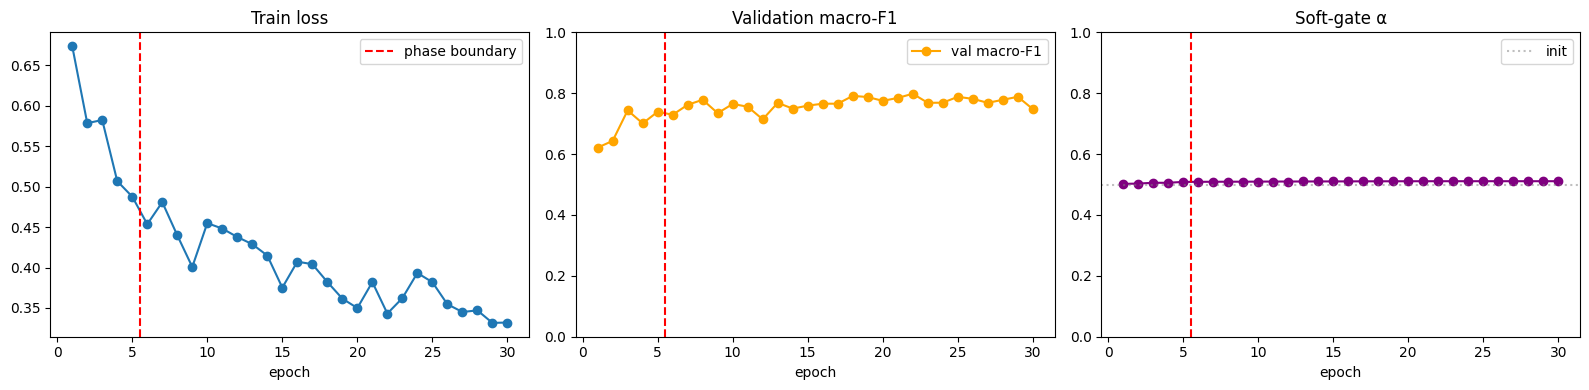

In [ ]:
# === Training curves ===
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
all_loss   = p1_train_losses + p2_train_losses
all_f1     = p1_val_f1s     + p2_val_f1s
all_alpha  = p1_alphas      + p2_alphas
xs         = list(range(1, len(all_loss)+1))
phase1_end = len(p1_train_losses)

axes[0].plot(xs, all_loss, 'o-')
axes[0].axvline(phase1_end + 0.5, color='red', ls='--', label='phase boundary')
axes[0].set_title('Train loss'); axes[0].set_xlabel('epoch'); axes[0].legend()

axes[1].plot(xs, all_f1, 'o-', color='orange', label='val macro-F1')
axes[1].axvline(phase1_end + 0.5, color='red', ls='--')
axes[1].set_title('Validation macro-F1'); axes[1].set_xlabel('epoch'); axes[1].legend()
axes[1].set_ylim(0, 1)

axes[2].plot(xs, all_alpha, 'o-', color='purple')
axes[2].axvline(phase1_end + 0.5, color='red', ls='--')
axes[2].axhline(0.5, color='gray', ls=':', alpha=0.5, label='init')
axes[2].set_title('Soft-gate α'); axes[2].set_xlabel('epoch'); axes[2].legend()
axes[2].set_ylim(0, 1)
plt.tight_layout(); plt.show()

---
## 6. Test-Set Evaluation

In [ ]:
model.load_state_dict(torch.load(CLF_WEIGHTS, map_location=device))
all_pred, all_prob, all_true = evaluate(model, test_loader)

print('=== Test set (predicted masks) ===')
print(f'Accuracy : {accuracy_score(all_true, all_pred):.4f}')
print(f'Macro-F1 : {f1_score(all_true, all_pred, average="macro"):.4f}')
try:
    print(f'AUC      : {roc_auc_score(all_true, all_prob):.4f}')
except ValueError:
    print('AUC      : (only one class)')
print()
print(classification_report(all_true, all_pred, target_names=BINARY_NAMES, digits=4))

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


=== Test set (predicted masks) ===
Accuracy : 0.8077
Macro-F1 : 0.7743
AUC      : 0.8678

               precision    recall  f1-score   support

Non-malignant     0.9118    0.8158    0.8611       114
    Malignant     0.6111    0.7857    0.6875        42

     accuracy                         0.8077       156
    macro avg     0.7614    0.8008    0.7743       156
 weighted avg     0.8308    0.8077    0.8144       156



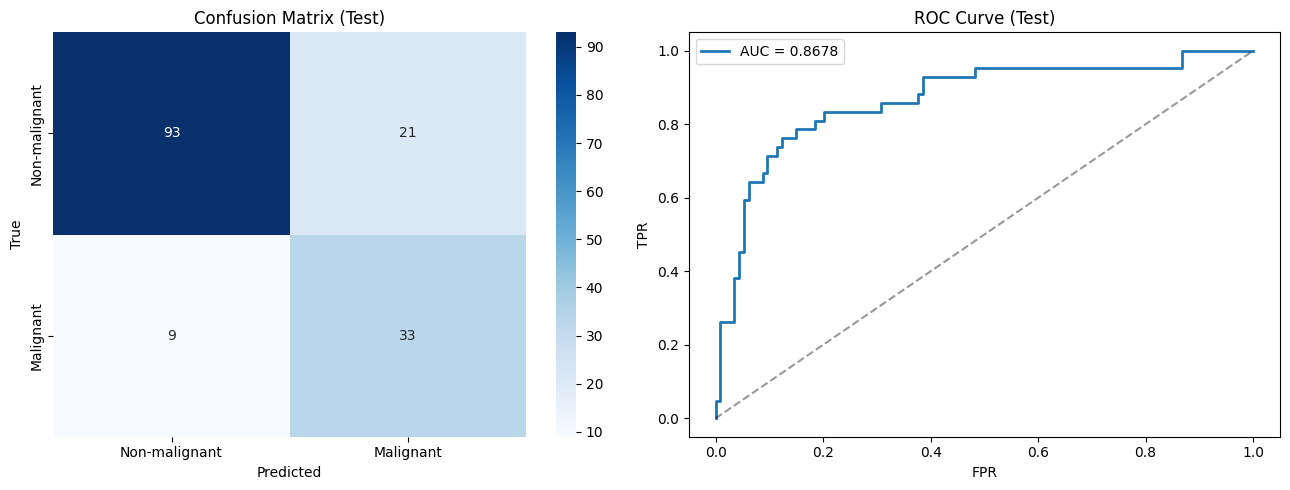

In [ ]:
# Confusion matrix + ROC
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cm = confusion_matrix(all_true, all_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=BINARY_NAMES, yticklabels=BINARY_NAMES, ax=axes[0])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].set_title('Confusion Matrix (Test)')

if len(set(all_true)) > 1:
    fpr, tpr, _ = roc_curve(all_true, all_prob)
    auc_v = roc_auc_score(all_true, all_prob)
    axes[1].plot(fpr, tpr, lw=2, label=f'AUC = {auc_v:.4f}')
    axes[1].plot([0,1], [0,1], 'k--', alpha=0.4)
    axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
    axes[1].set_title('ROC Curve (Test)'); axes[1].legend()
plt.tight_layout(); plt.show()

---
## 7. Ablation — predicted mask vs GT mask

Now NaN-safe: if `roc_auc_score` fails, we report it as N/A instead of crashing.


In [ ]:
gt_test_set = BUSILesionDataset(os.path.join(PROCESSED_DIR, 'test'),
                                augment=False, mask_source='gt')
gt_loader = DataLoader(gt_test_set, batch_size=BATCH_CLF, shuffle=False, num_workers=NUM_WORKERS)

gt_pred, gt_prob, gt_true = evaluate(model, gt_loader)

def safe_auc(y, p):
    if np.isnan(p).any() or len(set(y)) < 2:
        return float('nan')
    return roc_auc_score(y, p)

print(f'                  Accuracy   Macro-F1   AUC')
print(f'Pred mask (test): {accuracy_score(all_true, all_pred):.4f}     '
      f'{f1_score(all_true, all_pred, average="macro"):.4f}    '
      f'{safe_auc(all_true, all_prob):.4f}')
print(f'GT   mask (test): {accuracy_score(gt_true, gt_pred):.4f}     '
      f'{f1_score(gt_true, gt_pred, average="macro"):.4f}    '
      f'{safe_auc(gt_true, gt_prob):.4f}')

                  Accuracy   Macro-F1   AUC
Pred mask (test): 0.8077     0.7743    0.8678
GT   mask (test): 0.8333     0.8044    0.8713


In [ ]:
# ============================================================
# BASELINE: same architecture, mask=None throughout training
# Fair ablation — only the mask input is removed
# ============================================================

BASELINE_WEIGHTS = os.path.join(INTEG_DIR, 'classifier_v2_nomask.pth')

def train_nomask(m, opt):
    m.train()
    loss_sum, steps, skipped = 0.0, 0, 0
    opt.zero_grad()
    for i, (img, _, lbl) in enumerate(train_loader):    # ignore mask
        img = img.to(device, non_blocking=True)
        lbl = lbl.to(device, non_blocking=True)
        out = m(img, mask=None)                          # <<< no mask
        loss = loss_fn(out, lbl) / ACCUM_STEPS
        if not torch.isfinite(loss):
            skipped += 1; opt.zero_grad(); continue
        loss.backward()
        if (i + 1) % ACCUM_STEPS == 0:
            torch.nn.utils.clip_grad_norm_(m.parameters(), GRAD_CLIP)
            opt.step(); opt.zero_grad()
        loss_sum += loss.item() * ACCUM_STEPS; steps += 1
    if skipped: print(f'  skipped {skipped} non-finite steps')
    return loss_sum / max(steps, 1)

def evaluate_nomask(m, loader):
    m.eval()
    pred, prob, true = [], [], []
    with torch.no_grad():
        for img, _, lbl in loader:
            img = img.to(device)
            out = m(img, mask=None)
            p = F.softmax(out, dim=1)[:, 1].cpu().numpy()
            pred.extend(out.argmax(1).cpu().numpy())
            prob.extend(p); true.extend(lbl.numpy())
    return np.array(pred), np.array(prob), np.array(true)

# --- Same seed for fair comparison ---
torch.manual_seed(SEED)
baseline_model = EfficientNetLesionAttn(num_classes=2, pretrained=True).to(device)

# --- Phase 1 (frozen backbone) ---
print('='*70 + '\nBASELINE Phase 1 — frozen backbone, mask=None\n' + '='*70)
baseline_model.set_backbone_trainable(False)
opt_p1 = torch.optim.AdamW(
    [p for p in baseline_model.parameters() if p.requires_grad],
    lr=PHASE1_LR, weight_decay=WEIGHT_DECAY)
for epoch in range(PHASE1_EPOCHS):
    tr = train_nomask(baseline_model, opt_p1)
    pred, prob, true = evaluate_nomask(baseline_model, val_loader)
    s, _ = metrics_str(true, pred, prob)
    print(f'P1 [{epoch+1}/{PHASE1_EPOCHS}] train={tr:.4f} | val: {s}')

# --- Phase 2 (unfreeze + cosine + early stop) ---
print('\n' + '='*70 + '\nBASELINE Phase 2 — full unfreeze, mask=None\n' + '='*70)
baseline_model.set_backbone_trainable(True)
bb = list(baseline_model.features.parameters())
hd = list(baseline_model.attention.parameters()) + list(baseline_model.classifier.parameters())
opt_p2 = torch.optim.AdamW(
    [{'params': bb, 'lr': PHASE2_LR * 0.1},
     {'params': hd, 'lr': PHASE2_LR}],
    weight_decay=WEIGHT_DECAY)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt_p2, T_max=PHASE2_EPOCHS, eta_min=1e-6)

best_val_f1, patience_count = -1.0, 0
for epoch in range(PHASE2_EPOCHS):
    tr = train_nomask(baseline_model, opt_p2)
    sched.step()
    pred, prob, true = evaluate_nomask(baseline_model, val_loader)
    val_acc = accuracy_score(true, pred)
    val_f1  = f1_score(true, pred, average='macro')
    star = ''
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(baseline_model.state_dict(), BASELINE_WEIGHTS)
        patience_count = 0; star = ' ✓ best'
    else:
        patience_count += 1
    print(f'P2 [{epoch+1:02d}/{PHASE2_EPOCHS}] train={tr:.4f} | '
          f'val_acc={val_acc:.4f} val_f1={val_f1:.4f}{star}')
    if patience_count >= PATIENCE:
        print(f'Early stopping at epoch {epoch+1}'); break
print(f'\nBaseline best val macro-F1: {best_val_f1:.4f}')

# --- Test evaluation ---
baseline_model.load_state_dict(torch.load(BASELINE_WEIGHTS, map_location=device))
nm_pred, nm_prob, nm_true = evaluate_nomask(baseline_model, test_loader)

# --- 3-way comparison table ---
print('\n' + '='*70)
print('FINAL COMPARISON — Test set')
print('='*70)
print(f'{"Setup":<32} {"Accuracy":>10} {"Macro-F1":>10} {"AUC":>8}')
print('-' * 64)
def row(name, t, p, prob):
    acc = accuracy_score(t, p)
    f1  = f1_score(t, p, average='macro')
    try: auc = roc_auc_score(t, prob)
    except: auc = float('nan')
    print(f'{name:<32} {acc:>10.4f} {f1:>10.4f} {auc:>8.4f}')

row('(a) No mask — baseline',          nm_true,  nm_pred,  nm_prob)
row('(b) U-Net pred mask — main',      all_true, all_pred, all_prob)
row('(c) GT mask — oracle (upper bnd)', gt_true,  gt_pred,  gt_prob)

print('\nGap analysis:')
print(f'  Mask uplift  (b - a) AUC: {roc_auc_score(all_true, all_pred*0+all_prob) - roc_auc_score(nm_true, nm_prob):+.4f}')
print(f'  Oracle gap   (c - b) AUC: {roc_auc_score(gt_true, gt_prob) - roc_auc_score(all_true, all_prob):+.4f}')

BASELINE Phase 1 — frozen backbone, mask=None
P1 [1/5] train=0.6801 | val: acc=0.6987 f1=0.6254 auc=0.7049


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


P1 [2/5] train=0.5950 | val: acc=0.7564 f1=0.6349 auc=0.7099


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


P1 [3/5] train=0.5996 | val: acc=0.7756 f1=0.7127 auc=0.7715


...

P2 [22/25] train=0.4001 | val_acc=0.7949 val_f1=0.7432


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


P2 [23/25] train=0.3738 | val_acc=0.8077 val_f1=0.7658
Early stopping at epoch 23

Baseline best val macro-F1: 0.7739


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



FINAL COMPARISON — Test set
Setup                              Accuracy   Macro-F1      AUC
----------------------------------------------------------------
(a) No mask — baseline               0.8077     0.7556   0.8509
(b) U-Net pred mask — main           0.8077     0.7743   0.8678
(c) GT mask — oracle (upper bnd)     0.8333     0.8044   0.8713

Gap analysis:
  Mask uplift  (b - a) AUC: +0.0169
  Oracle gap   (c - b) AUC: +0.0036


In [ ]:
# ============================================================
# PURE BASELINE — no mask, no attention, minimal head
# Only EfficientNet-B0 + AvgPool + Linear(1280, 2)
# ============================================================
class PureEfficientNet(nn.Module):
    """Smallest possible baseline: just the backbone + a single linear classifier."""
    def __init__(self, num_classes=2, pretrained=True):
        super().__init__()
        weights = tv_models.EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None
        bb = tv_models.efficientnet_b0(weights=weights)
        old = bb.features[0][0]
        new = nn.Conv2d(1, 32, 3, 2, 1, bias=False)
        if pretrained:
            new.weight.data = old.weight.data.mean(dim=1, keepdim=True)
        bb.features[0][0] = new
        self.features = bb.features
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(1280, num_classes),     # <<< no intermediate FC
        )

    def forward(self, x):
        return self.head(self.features(x))

def train_pure(m, opt):
    m.train()
    loss_sum, steps, skipped = 0., 0, 0
    opt.zero_grad()
    for i, (img, _, lbl) in enumerate(train_loader):
        img = img.to(device, non_blocking=True)
        lbl = lbl.to(device, non_blocking=True)
        out = m(img)
        loss = loss_fn(out, lbl) / ACCUM_STEPS
        if not torch.isfinite(loss):
            skipped += 1; opt.zero_grad(); continue
        loss.backward()
        if (i + 1) % ACCUM_STEPS == 0:
            torch.nn.utils.clip_grad_norm_(m.parameters(), GRAD_CLIP)
            opt.step(); opt.zero_grad()
        loss_sum += loss.item() * ACCUM_STEPS; steps += 1
    if skipped: print(f'  skipped {skipped} non-finite steps')
    return loss_sum / max(steps, 1)

def eval_pure(m, loader):
    m.eval()
    pred, prob, true = [], [], []
    with torch.no_grad():
        for img, _, lbl in loader:
            img = img.to(device)
            out = m(img)
            p = F.softmax(out, dim=1)[:, 1].cpu().numpy()
            pred.extend(out.argmax(1).cpu().numpy())
            prob.extend(p); true.extend(lbl.numpy())
    return np.array(pred), np.array(prob), np.array(true)

# --- Train (single-phase, full unfreeze, cosine LR) ---
PURE_WEIGHTS = os.path.join(INTEG_DIR, 'classifier_v2_pure.pth')
torch.manual_seed(SEED)
pure_model = PureEfficientNet(num_classes=2, pretrained=True).to(device)
PURE_EPOCHS = 10
opt   = torch.optim.AdamW(pure_model.parameters(), lr=1e-4, weight_decay=WEIGHT_DECAY)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=PURE_EPOCHS, eta_min=1e-6)

print(f'Pure baseline params: {sum(p.numel() for p in pure_model.parameters()):,}')
print('=' * 70 + '\nPURE BASELINE — image-only, no attention\n' + '=' * 70)

best_val_f1, patience_count = -1., 0
pure_train_losses, pure_val_f1s = [], []
for epoch in range(PURE_EPOCHS):
    tr = train_pure(pure_model, opt)
    sched.step()
    pred, prob, true = eval_pure(pure_model, val_loader)
    val_acc = accuracy_score(true, pred); val_f1 = f1_score(true, pred, average='macro')
    pure_train_losses.append(tr); pure_val_f1s.append(val_f1)
    star = ''
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(pure_model.state_dict(), PURE_WEIGHTS)
        patience_count = 0; star = ' ✓ best'
    else:
        patience_count += 1
    print(f'[{epoch+1:02d}/{PURE_EPOCHS}] train={tr:.4f} | val_acc={val_acc:.4f} val_f1={val_f1:.4f}{star}')
    if patience_count >= PATIENCE:
        print(f'Early stopping at epoch {epoch+1}'); break

print(f'\nBest val macro-F1: {best_val_f1:.4f}')

Pure baseline params: 4,009,534
PURE BASELINE — image-only, no attention
[01/10] train=0.6661 | val_acc=0.7756 val_f1=0.6983 ✓ best


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


[02/10] train=0.5486 | val_acc=0.7949 val_f1=0.7393 ✓ best


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


[03/10] train=0.4785 | val_acc=0.8333 val_f1=0.7778 ✓ best


...

[08/10] train=0.3035 | val_acc=0.8590 val_f1=0.8234


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


[09/10] train=0.3217 | val_acc=0.8590 val_f1=0.8234


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


[10/10] train=0.3436 | val_acc=0.8590 val_f1=0.8208

Best val macro-F1: 0.8234


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


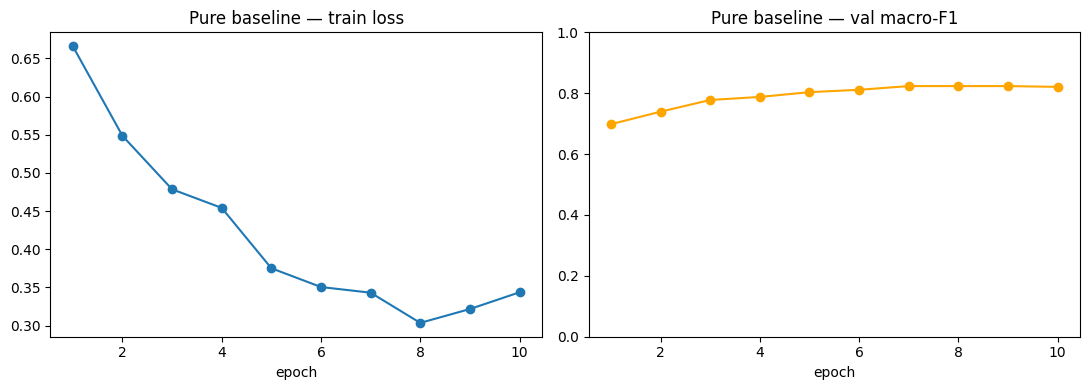


=== Pure baseline — test ===
               precision    recall  f1-score   support

Non-malignant     0.9700    0.8509    0.9065       114
    Malignant     0.6964    0.9286    0.7959        42

     accuracy                         0.8718       156
    macro avg     0.8332    0.8897    0.8512       156
 weighted avg     0.8963    0.8718    0.8768       156



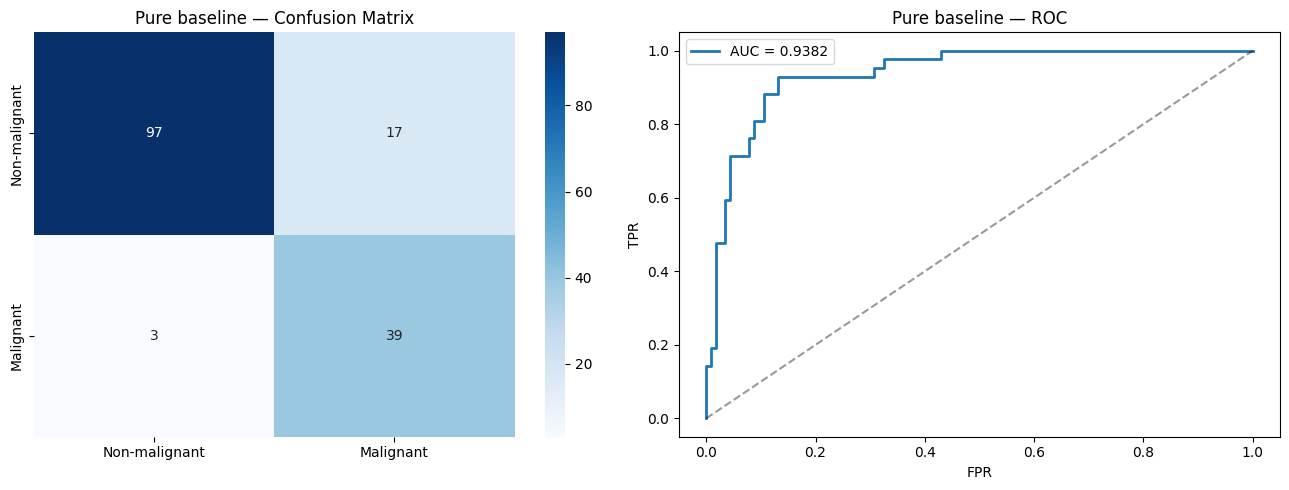


FULL COMPARISON — Test set
Setup                                                 Acc       F1      AUC
----------------------------------------------------------------------------
(a) Pure EfficientNet (no attn, no mask)           0.8718   0.8512   0.9382
(b) + soft attn, no mask input                     0.8077   0.7556   0.8509
(c) + soft attn + U-Net pred mask [main]           0.8077   0.7743   0.8678
(d) + soft attn + GT mask [oracle]                 0.8333   0.8044   0.8713


In [ ]:
pure_model.load_state_dict(torch.load(PURE_WEIGHTS, map_location=device))
pure_pred, pure_prob, pure_true = eval_pure(pure_model, test_loader)

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
xs = list(range(1, len(pure_train_losses)+1))
axes[0].plot(xs, pure_train_losses, 'o-')
axes[0].set_title('Pure baseline — train loss'); axes[0].set_xlabel('epoch')
axes[1].plot(xs, pure_val_f1s, 'o-', color='orange')
axes[1].set_title('Pure baseline — val macro-F1'); axes[1].set_xlabel('epoch')
axes[1].set_ylim(0, 1)
plt.tight_layout(); plt.show()

# Per-class report
print('\n=== Pure baseline — test ===')
print(classification_report(pure_true, pure_pred, target_names=BINARY_NAMES, digits=4))

# CM + ROC
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cm = confusion_matrix(pure_true, pure_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=BINARY_NAMES, yticklabels=BINARY_NAMES, ax=axes[0])
axes[0].set_title('Pure baseline — Confusion Matrix')
if len(set(pure_true)) > 1:
    fpr, tpr, _ = roc_curve(pure_true, pure_prob)
    auc_v = roc_auc_score(pure_true, pure_prob)
    axes[1].plot(fpr, tpr, lw=2, label=f'AUC = {auc_v:.4f}')
    axes[1].plot([0,1], [0,1], 'k--', alpha=0.4)
    axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
    axes[1].set_title('Pure baseline — ROC'); axes[1].legend()
plt.tight_layout(); plt.show()

# === Full comparison ===
def safe_auc(y, p):
    if np.isnan(p).any() or len(set(y)) < 2: return float('nan')
    return roc_auc_score(y, p)

print('\n' + '=' * 76)
print('FULL COMPARISON — Test set')
print('=' * 76)
print(f'{"Setup":<48} {"Acc":>8} {"F1":>8} {"AUC":>8}')
print('-' * 76)
def row(name, t, p, prob):
    print(f'{name:<48} {accuracy_score(t,p):>8.4f} {f1_score(t,p,average="macro"):>8.4f} {safe_auc(t,prob):>8.4f}')

row('(a) Pure EfficientNet (no attn, no mask)',   pure_true, pure_pred, pure_prob)
try: row('(b) + soft attn, no mask input',         nm_true,   nm_pred,   nm_prob)
except NameError: pass
row('(c) + soft attn + U-Net pred mask [main]',    all_true,  all_pred,  all_prob)
row('(d) + soft attn + GT mask [oracle]',          gt_true,   gt_pred,   gt_prob)

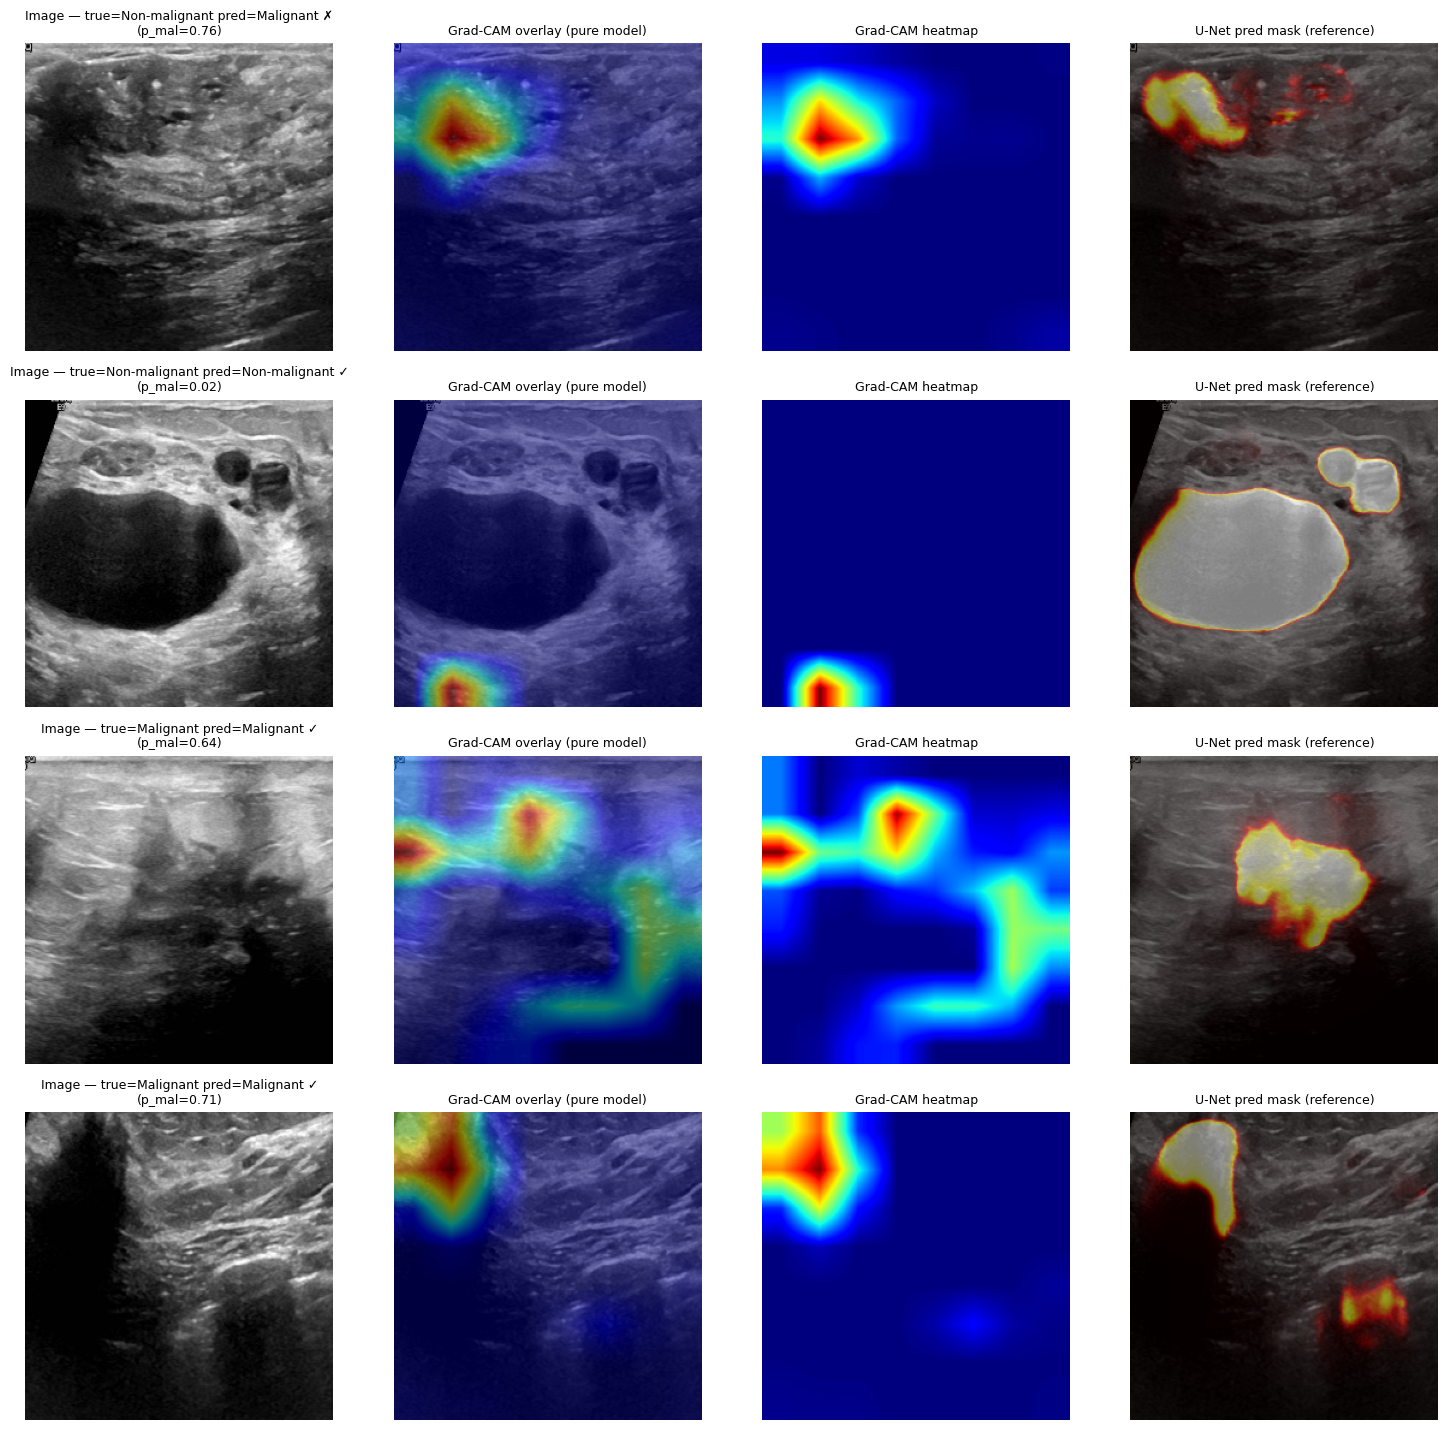

In [ ]:
# ============================================================
# Grad-CAM on the pure baseline
# Shows where the bare model looks vs where U-Net says the lesion is
# ============================================================
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.acts, self.grads = None, None
        self.h1 = target_layer.register_forward_hook(self._fwd)
        self.h2 = target_layer.register_full_backward_hook(self._bwd)
    def _fwd(self, m, i, o): self.acts = o
    def _bwd(self, m, gi, go): self.grads = go[0]
    def __call__(self, img_t, target_class):
        self.model.eval(); self.model.zero_grad()
        out = self.model(img_t.unsqueeze(0) if img_t.ndim == 3 else img_t)
        out[0, target_class].backward()
        a, g = self.acts[0], self.grads[0]               # (C,H,W)
        w = g.mean(dim=(1, 2))
        cam = F.relu((w[:, None, None] * a).sum(0))
        if cam.max() > 0: cam = cam / cam.max()
        cam = F.interpolate(cam[None, None], size=(SIZE, SIZE),
                            mode='bilinear', align_corners=False)[0, 0]
        prob = F.softmax(out, dim=1)[0].detach().cpu().numpy()
        return cam.detach().cpu().numpy(), prob
    def close(self): self.h1.remove(); self.h2.remove()

# Pick balanced sample: 2 malignant + 2 non-malignant from test set
labels_arr = np.array(test_set.binary_labels)
mal_idx = np.where(labels_arr == 1)[0]
non_idx = np.where(labels_arr == 0)[0]
rng = np.random.RandomState(7)
chosen = list(rng.choice(non_idx, 2, replace=False)) + list(rng.choice(mal_idx, 2, replace=False))

cam_ext = GradCAM(pure_model, target_layer=pure_model.features[-1])

fig, axes = plt.subplots(len(chosen), 4, figsize=(15, 3.6 * len(chosen)))
for r, idx in enumerate(chosen):
    d = np.load(test_set.files[idx])
    img, pred_mask = d['image'], d['pred_mask']
    label = TO_BINARY[int(d['cls'])]

    img_t = torch.from_numpy(img[None]).float().to(device)
    cam, prob = cam_ext(img_t, target_class=1)        # CAM for malignant
    pred_lbl = int(prob[1] > 0.5)
    correct = '✓' if pred_lbl == label else '✗'
    name  = BINARY_NAMES[label]
    pname = BINARY_NAMES[pred_lbl]

    axes[r,0].imshow(img, cmap='gray')
    axes[r,0].set_title(f'Image — true={name} pred={pname} {correct}\n(p_mal={prob[1]:.2f})', fontsize=9)
    axes[r,1].imshow(img, cmap='gray'); axes[r,1].imshow(cam, cmap='jet', alpha=0.5)
    axes[r,1].set_title('Grad-CAM overlay (pure model)', fontsize=9)
    axes[r,2].imshow(cam, cmap='jet')
    axes[r,2].set_title('Grad-CAM heatmap', fontsize=9)
    axes[r,3].imshow(img, cmap='gray'); axes[r,3].imshow(pred_mask, cmap='hot', alpha=0.5)
    axes[r,3].set_title('U-Net pred mask (reference)', fontsize=9)
    for a in axes[r]: a.axis('off')

plt.tight_layout(); plt.show()
cam_ext.close()